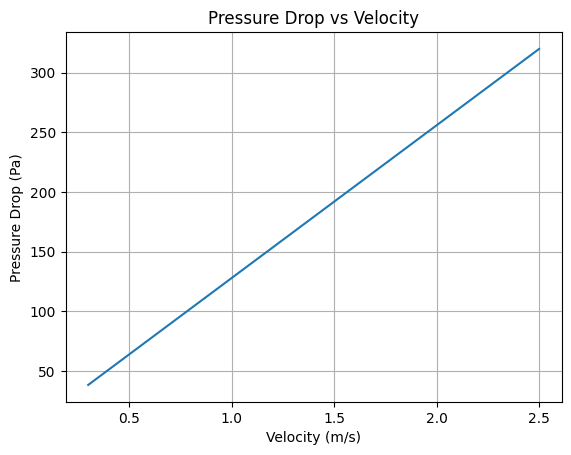

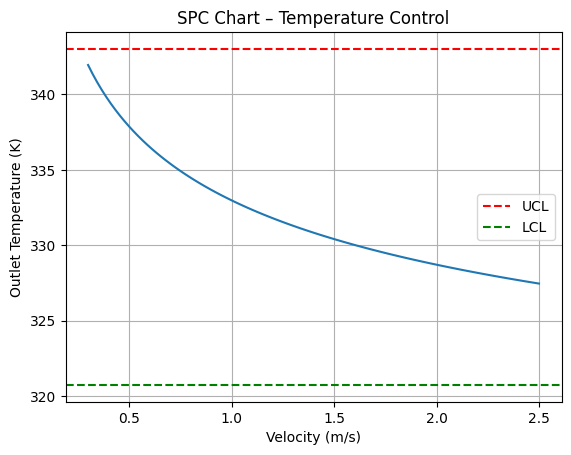

----- SYSTEM PERFORMANCE SUMMARY -----
Maximum Heat Transfer Rate: 563296.41 W
Maximum Pressure Drop: 320.0 Pa
Mean Outlet Temperature: 331.87 K
Number of Safety Fault Points: 0


,Velocity (m/s),Reynolds No,Pressure Drop (Pa),Heat Transfer Coeff (W/m2K),Outlet Temperature (K)
0,0.300000,15000.000000,38.400000,1315.200914,341.952182
1,0.322222,16111.111111,41.244444,1392.577868,341.356874
2,0.344444,17222.222222,44.088889,1468.893962,340.808908
3,0.366667,18333.333333,46.933333,1544.230914,340.301807
4,0.388889,19444.444444,49.777778,1618.659595,339.830311


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 10          # Pipe length (m)
D = 0.05        # Diameter (m)
rho = 1000      # Density (kg/m3)
mu = 1e-3       # Viscosity (Pa.s)
k = 0.6         # Thermal conductivity (W/mK)
Cp = 4180       # Specific heat (J/kgK)

Tw = 350        # Wall temperature (K)
Tin = 300       # Inlet temperature (K)


V = np.linspace(0.3, 2.5, 100)  # Velocity range

Re = rho * V * D / mu
f = 64 / Re
deltaP = f * (L/D) * (rho * V**2 / 2)

#HEAT TRANSFER CALCULATION

Pr = Cp * mu / k
Nu = 0.023 * (Re**0.8) * (Pr**0.4)
h = Nu * k / D
A = np.pi * D * L
Q = h * A * (Tw - Tin)


#QUALITY CONTROL (SPC)

process_temp = Tin + Q / (rho * Cp * V * np.pi * (D/2)**2)
mean_T = np.mean(process_temp)
std_T = np.std(process_temp)

UCL = mean_T + 3*std_T
LCL = mean_T - 3*std_T

df = pd.DataFrame({
    "Velocity (m/s)": V,
    "Reynolds No": Re,
    "Pressure Drop (Pa)": deltaP,
    "Heat Transfer Coeff (W/m2K)": h,
    "Outlet Temperature (K)": process_temp
})

plt.figure()
plt.plot(V, deltaP)
plt.xlabel("Velocity (m/s)")
plt.ylabel("Pressure Drop (Pa)")
plt.title("Pressure Drop vs Velocity")
plt.grid()
plt.show()

plt.figure()
plt.plot(V, process_temp)
plt.axhline(UCL, color='r', linestyle='--', label='UCL')
plt.axhline(LCL, color='g', linestyle='--', label='LCL')
plt.xlabel("Velocity (m/s)")
plt.ylabel("Outlet Temperature (K)")
plt.title("SPC Chart – Temperature Control")
plt.legend()
plt.grid()
plt.show()

faults = df[(df["Outlet Temperature (K)"] > UCL) |
            (df["Outlet Temperature (K)"] < LCL)]

print("----- SYSTEM PERFORMANCE SUMMARY -----")
print("Maximum Heat Transfer Rate:", round(np.max(Q),2), "W")
print("Maximum Pressure Drop:", round(np.max(deltaP),2), "Pa")
print("Mean Outlet Temperature:", round(mean_T,2), "K")
print("Number of Safety Fault Points:", len(faults))

df.head()
